<a href="https://colab.research.google.com/github/YAshhh29/Algorithms/blob/main/MDP_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

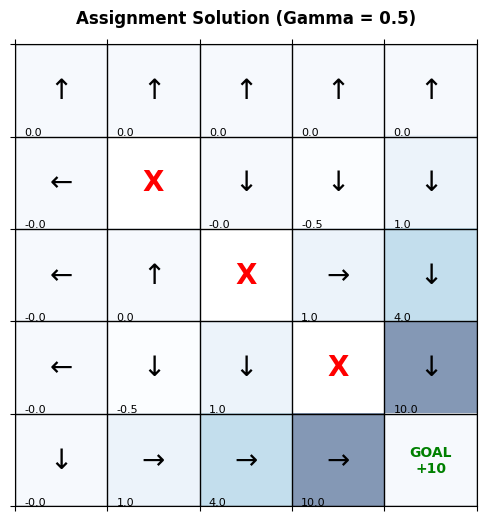

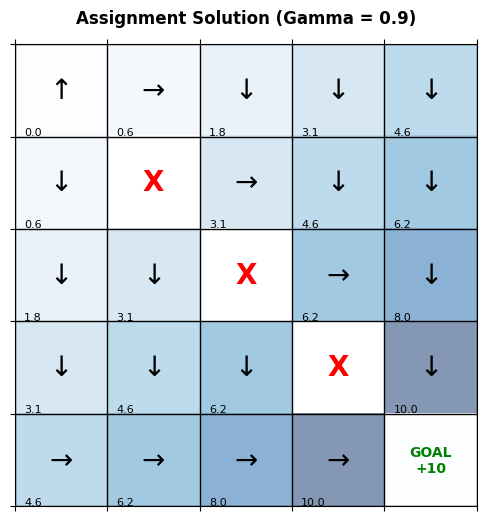

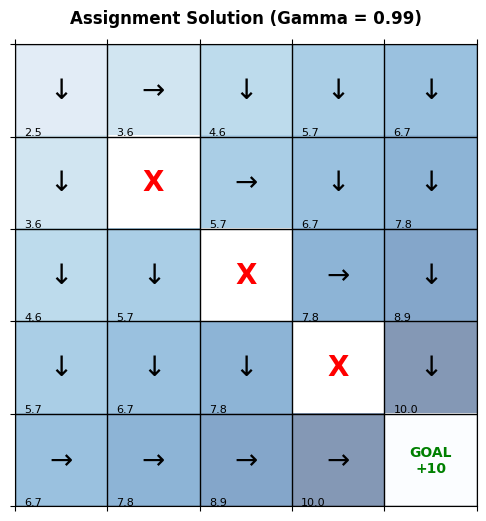

In [1]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 5
GOAL_STATE = (4, 4)
OBSTACLES = [(1, 1), (2, 2), (3, 3)]
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]
ACTION_SYMBOLS = ['↑', '↓', '←', '→']

def step_env(state, action_idx):
    """The Environment Rules as stated."""
    if state == GOAL_STATE:
        return state, 0

    r, c = state
    dr, dc = ACTIONS[action_idx]
    next_r, next_c = r + dr, c + dc

    # Rule: "0 reward for staying in place due to an obstacle."
    if (next_r < 0 or next_r >= GRID_SIZE or
        next_c < 0 or next_c >= GRID_SIZE or
        (next_r, next_c) in OBSTACLES):
        return state, 0

    next_state = (next_r, next_c)

    if next_state == GOAL_STATE:
        return next_state, 10
    else:
        return next_state, -1

def evaluate(policy, V, gamma, theta=1e-4):
    while True:
        delta = 0
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if (r, c) == GOAL_STATE or (r, c) in OBSTACLES: continue
                v_old = V[r, c]
                action = policy[r, c]
                next_state, reward = step_env((r, c), action)
                V[r, c] = reward + gamma * V[next_state[0], next_state[1]]
                delta = max(delta, abs(v_old - V[r, c]))
        if delta < theta: break
    return V

def improve(policy, V, gamma):
    is_stable = True
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == GOAL_STATE or (r, c) in OBSTACLES: continue
            old_action = policy[r, c]
            best_a, max_val = 0, float('-inf')

            for a in range(len(ACTIONS)):
                next_state, reward = step_env((r, c), a)
                val = reward + gamma * V[next_state[0], next_state[1]]
                if val > max_val:
                    max_val, best_a = val, a

            policy[r, c] = best_a
            if old_action != best_a: is_stable = False
    return policy, is_stable

def policy_iteration(gamma):
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    while True:
        V = evaluate(policy, V, gamma)
        policy, is_stable = improve(policy, V, gamma)
        if is_stable: break
    return V, policy

def plot_assignment_policy(policy, V, gamma):
    fig, ax = plt.subplots(figsize=(6, 6))
    masked_V = np.copy(V)
    for r, c in OBSTACLES: masked_V[r, c] = np.nan

    ax.matshow(masked_V, cmap='Blues', alpha=0.5)
    ax.set_xticks(np.arange(-.5, GRID_SIZE, 1)); ax.set_yticks(np.arange(-.5, GRID_SIZE, 1))
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.grid(color='black', linewidth=1)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == GOAL_STATE: ax.text(c, r, 'GOAL\n+10', ha='center', va='center', color='green', weight='bold')
            elif (r, c) in OBSTACLES: ax.text(c, r, 'X', ha='center', va='center', color='red', weight='bold', size=20)
            else:
                ax.text(c, r, ACTION_SYMBOLS[policy[r, c]], ha='center', va='center', size=20)
                ax.text(c-0.4, r+0.4, f"{V[r, c]:.1f}", ha='left', va='top', size=8)
    plt.title(f"Assignment Solution (Gamma = {gamma})", pad=15, weight='bold')
    plt.show()

# Run the required tests
for g in [0.5, 0.9, 0.99]:
    V_opt, p_opt = policy_iteration(gamma=g)
    plot_assignment_policy(p_opt, V_opt, gamma=g)

Running Short-Sighted Agent...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


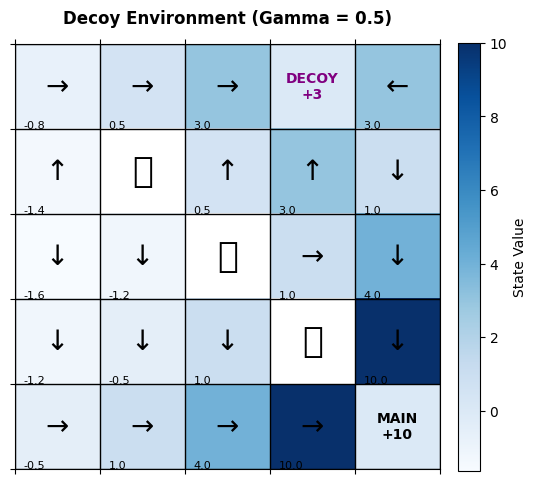

Running Far-Sighted Agent...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129521 (\N{BRICK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


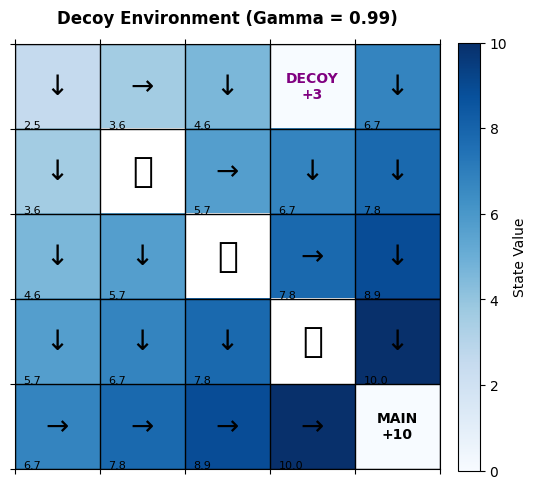

In [2]:
DECOY_GOAL = (0, 3) # A small prize close to the start

def step_decoy_env(state, action_idx):
    """Modified Environment: Walls hurt (-1), and there is a Decoy Goal (+3)."""
    if state == GOAL_STATE or state == DECOY_GOAL:
        return state, 0

    r, c = state
    dr, dc = ACTIONS[action_idx]
    next_r, next_c = r + dr, c + dc

    # FIXED: Hitting a wall now costs -1 so the agent won't stall
    if (next_r < 0 or next_r >= GRID_SIZE or
        next_c < 0 or next_c >= GRID_SIZE or
        (next_r, next_c) in OBSTACLES):
        return state, -1

    next_state = (next_r, next_c)

    # NEW REWARDS
    if next_state == GOAL_STATE: return next_state, 10
    elif next_state == DECOY_GOAL: return next_state, 3
    else: return next_state, -1

# Modified Evaluate/Improve to use the decoy environment
def evaluate_decoy(policy, V, gamma, theta=1e-4):
    while True:
        delta = 0
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if (r, c) == GOAL_STATE or (r, c) == DECOY_GOAL or (r, c) in OBSTACLES: continue
                v_old = V[r, c]
                next_state, reward = step_decoy_env((r, c), policy[r, c])
                V[r, c] = reward + gamma * V[next_state[0], next_state[1]]
                delta = max(delta, abs(v_old - V[r, c]))
        if delta < theta: break
    return V

def improve_decoy(policy, V, gamma):
    is_stable = True
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == GOAL_STATE or (r, c) == DECOY_GOAL or (r, c) in OBSTACLES: continue
            old_action = policy[r, c]
            best_a, max_val = 0, float('-inf')
            for a in range(len(ACTIONS)):
                next_state, reward = step_decoy_env((r, c), a)
                val = reward + gamma * V[next_state[0], next_state[1]]
                if val > max_val: max_val, best_a = val, a
            policy[r, c] = best_a
            if old_action != best_a: is_stable = False
    return policy, is_stable

def policy_iteration_decoy(gamma):
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    policy = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    while True:
        V = evaluate_decoy(policy, V, gamma)
        policy, is_stable = improve_decoy(policy, V, gamma)
        if is_stable: break
    return V, policy

def plot_decoy_policy(policy, V, gamma):
    fig, ax = plt.subplots(figsize=(6, 6))
    masked_V = np.copy(V)
    for r, c in OBSTACLES: masked_V[r, c] = np.nan

    cax = ax.matshow(masked_V, cmap='Blues')
    fig.colorbar(cax, fraction=0.046, pad=0.04, label="State Value")

    ax.set_xticks(np.arange(-.5, GRID_SIZE, 1)); ax.set_yticks(np.arange(-.5, GRID_SIZE, 1))
    ax.set_xticklabels([]); ax.set_yticklabels([]); ax.grid(color='black', linewidth=1)

    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            if (r, c) == GOAL_STATE: ax.text(c, r, 'MAIN\n+10', ha='center', va='center', weight='bold')
            elif (r, c) == DECOY_GOAL: ax.text(c, r, 'DECOY\n+3', ha='center', va='center', weight='bold', color='purple')
            elif (r, c) in OBSTACLES: ax.text(c, r, '🧱', ha='center', va='center', size=25)
            else:
                ax.text(c, r, ACTION_SYMBOLS[policy[r, c]], ha='center', va='center', size=20)
                ax.text(c-0.4, r+0.4, f"{V[r, c]:.1f}", ha='left', va='top', size=8)
    plt.title(f"Decoy Environment (Gamma = {gamma})", pad=15, weight='bold')
    plt.show()

# Run the comparison
print("Running Short-Sighted Agent...")
V_decoy, p_decoy = policy_iteration_decoy(gamma=0.5)
plot_decoy_policy(p_decoy, V_decoy, gamma=0.5)

print("Running Far-Sighted Agent...")
V_decoy, p_decoy = policy_iteration_decoy(gamma=0.99)
plot_decoy_policy(p_decoy, V_decoy, gamma=0.99)